# Notebook 15 – Mini Assessment
### Conceptual Q&A + Coding Exercises on the Healthcare Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)

df = pd.read_csv('healthcare_dataset.csv')
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
df.shape


(55500, 16)

## Q1. What is EDA?
Exploratory Data Analysis is the process of examining a dataset to understand its structure, quality, patterns, and relationships before modeling.

## Q2. Why is EDA performed before Machine Learning?
It catches data quality issues, reveals which features matter, and prevents building a model on flawed or misunderstood data.

## Q3. Difference between univariate, bivariate, and multivariate analysis
- Univariate: one variable at a time (e.g., a histogram of Age).
- Bivariate: two variables together (e.g., Age vs Billing Amount).
- Multivariate: three or more variables together (e.g., a pair plot or correlation heatmap).

## Q4. How do you identify missing values?
Use `.isna().sum()` or `.info()` to count nulls per column.

In [2]:
df.isna().sum()


Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
Length of Stay        0
dtype: int64

## Q5. How do you identify duplicate records?
Use `.duplicated().sum()` to count exact repeated rows.

In [3]:
df.duplicated().sum()


np.int64(534)

## Q6. What is an outlier?
A data point that lies far outside the typical range of the rest of the data.

## Q7. Explain the IQR method
IQR = Q3 − Q1. Any value below Q1 − 1.5×IQR or above Q3 + 1.5×IQR is treated as an outlier.

## Q8. What is skewness?
A measure of how asymmetric a distribution is. Zero means symmetric, positive means a longer right tail, negative means a longer left tail.

## Q9. What is correlation?
A statistic (like Pearson's r) that measures the strength and direction of a linear relationship between two numeric variables, ranging from -1 to 1.

## Q10. Difference between correlation and causation
Correlation means two variables move together; causation means one directly causes the change in the other. Correlation alone never proves causation.

## Q11. What is multicollinearity?
When two or more input features are highly correlated with each other, making it hard for a model to isolate each feature's individual effect.

## Q12. How do you identify class imbalance?
Check the value counts (or proportions) of the target/categorical variable — a big gap between class sizes indicates imbalance.

In [4]:
df['Test Results'].value_counts(normalize=True).round(3)


Test Results
Abnormal        0.336
Normal          0.334
Inconclusive    0.331
Name: proportion, dtype: float64

## Q13. Why should outliers not always be removed?
Some outliers are genuine, important events (e.g., a real high-cost patient case), not errors — removing them can throw away real signal and bias the model.

## Q14. Create a correlation heatmap

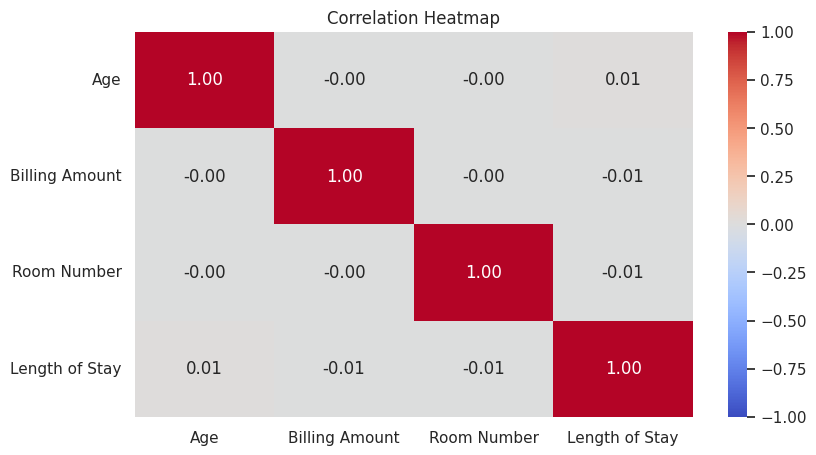

In [5]:
num_cols = ['Age', 'Billing Amount', 'Room Number', 'Length of Stay']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()


## Q15. Detect outliers using IQR

In [6]:
q1, q3 = df['Billing Amount'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = df[(df['Billing Amount'] < lower) | (df['Billing Amount'] > upper)]
lower, upper, len(outliers)


(-23627.701022764355, 74689.43411091428, 0)

## Q16. Analyze the distribution of a numerical feature

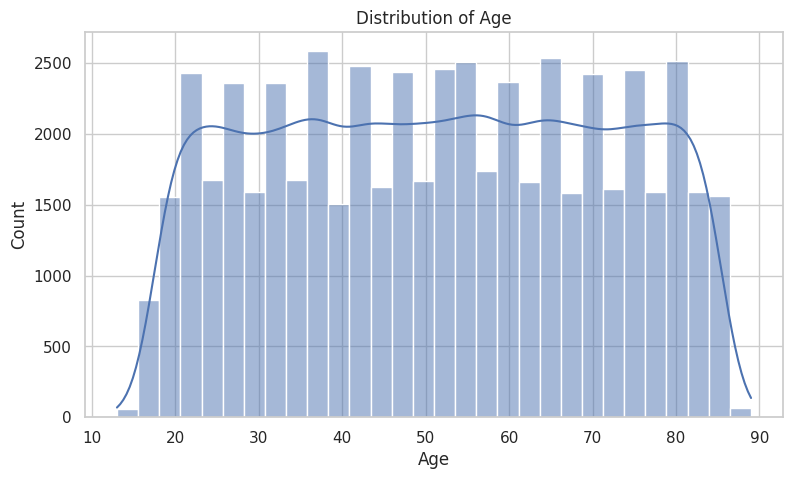

In [7]:
sns.histplot(df['Age'], kde=True, bins=30, color='#4C72B0')
plt.title('Distribution of Age')
plt.show()


Age is spread almost uniformly from 13 to 89, with no strong peak.

## Q17. Perform categorical analysis

In [8]:
df['Medical Condition'].value_counts(normalize=True).mul(100).round(2)


Medical Condition
Arthritis       16.77
Diabetes        16.76
Hypertension    16.66
Obesity         16.63
Cancer          16.63
Asthma          16.55
Name: proportion, dtype: float64

/tmp/ipykernel_509/2980484098.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Medical Condition', order=df['Medical Condition'].value_counts().index, palette='Set2')


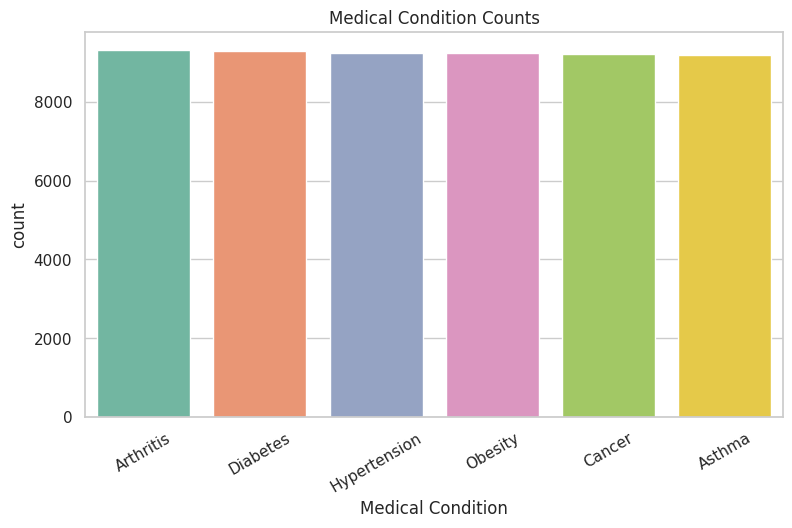

In [9]:
sns.countplot(data=df, x='Medical Condition', order=df['Medical Condition'].value_counts().index, palette='Set2')
plt.title('Medical Condition Counts')
plt.xticks(rotation=30)
plt.show()


All six conditions occur at nearly equal frequency, roughly 16-17% each.

## Q18. Generate a complete EDA summary

In [10]:
summary = {
    'rows': df.shape[0],
    'columns': df.shape[1],
    'missing_values': int(df.isna().sum().sum()),
    'duplicate_rows': int(df.duplicated().sum()),
    'negative_billing': int((df['Billing Amount'] < 0).sum()),
    'avg_age': round(df['Age'].mean(), 1),
    'avg_billing': round(df['Billing Amount'].mean(), 1),
    'avg_length_of_stay': round(df['Length of Stay'].mean(), 1),
    'max_length_of_stay': int(df['Length of Stay'].max()),
}
pd.Series(summary)


rows                  55500.0
columns                  16.0
missing_values            0.0
duplicate_rows          534.0
negative_billing        108.0
avg_age                  51.5
avg_billing           25539.3
avg_length_of_stay       15.5
max_length_of_stay       30.0
dtype: float64

55,500 rows, 15 columns, no missing values, 534 duplicate rows, 108 negative billing values, average age ~51.5, average billing ~$25,540, average stay ~15.5 days capped at 30.